In [1]:
import os
import tempfile

import scanpy as sc
#import scvi
from rich import print
import numpy as np
import pandas as pd
#from anndata import AnnData

import scFates as scf
import palantir
import matplotlib.pyplot as plt
sc.settings.verbosity = 3
#sc.settings.logfile = sys.stdout

## fix palantir breaking down some plots
import seaborn

/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import

In [2]:
adata3 = sc.read("/home/bnvlab2/scVI_brain_organoids/no_erythocytes_atlas/annot_scANVI_5_allgenes_meta_upd.h5ad")

In [49]:
adata3_neurons = adata3[adata3.obs['cell_type_general'].isin([ 'Mature Neurons', 'Early Neurons', 'IPC'])]

In [16]:
adata.raw.X.shape

(17296, 38606)

In [33]:
adata_test_subset2 = sc.read("/home/bnvlab2/scVI_brain_organoids/organoids/scFates_IPC_mature_2comp.h5ad")

In [34]:
gcol = 'cell_type_pred3_upd'
counts = adata_test_subset2.obs[gcol].value_counts().sort_index()
props = counts / counts.sum()

In [58]:
counts = adata3_neurons.obs[gcol].value_counts().sort_index()
props = counts / counts.sum()
props

cell_type_general
IPC               0.077441
Early Neurons     0.665030
Mature Neurons    0.257529
Name: count, dtype: float64

In [59]:
import numpy as np
import pandas as pd
from sklearn.utils import resample

gcol = "cell_type_general"
N_total = 18_000
rng = 42

counts = adata3_neurons.obs[gcol].value_counts().sort_index()
props = counts / counts.sum()

# initial quotas (floor) and remainder redistribution (largest remainder)
quotas = (props * N_total).astype(int)
remainder = N_total - quotas.sum()
if remainder > 0:
    extras = (props * N_total - quotas).sort_values(ascending=False).index[:remainder]
    quotas.loc[extras] += 1

sel = []
for g, n_take in quotas.items():
    idx = np.array(list(adata3_neurons.obs.groupby(gcol).groups[g]))
    # downsample without replacement to requested quota
    chosen = resample(idx, replace=False, n_samples=int(n_take), random_state=rng)
    sel.append(chosen)

sel = np.concatenate(sel)
adata_prop = adata3_neurons[sel].copy()
adata_prop.obs_names_make_unique()
print("Selected per class:\n", quotas.to_string())


/tmp/ipykernel_144627/1664335607.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  idx = np.array(list(adata3_neurons.obs.groupby(gcol).groups[g]))


Selected per class:
 cell_type_general
IPC                1394
Early Neurons     11971
Mature Neurons     4635

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:01)


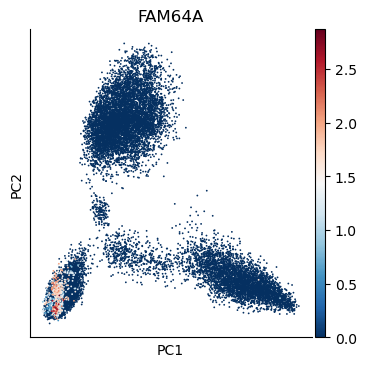

In [60]:
sc.pp.highly_variable_genes(adata_prop, n_top_genes=3000, flavor='seurat_v3', layer='counts')
#adata_prop = adata_prop[:, adata_prop.var.highly_variable].copy()
#sc.pp.scale(adata_prop)  # gene-wise z-score
sc.pp.pca(adata_prop)
sc.pl.pca(adata_prop,color="FAM64A",cmap="RdBu_r")

In [62]:
adata_prop

AnnData object with n_obs × n_vars = 18000 × 67814
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'CellClass', 'Region', 'Subregion', 'assay_ontology_term_id', 'donor_id', 'dissection', 'tissue_ontology_term_id', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'cluster_id', 'is_primary_data', 'cell_type', 'assay', 'tissue', 'self_reported_ethnicity', 'development_stage', 'percent.rb', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'GSM', 'GSE', 'batch_n', 'CytoTRACE2_Score', 'CytoTRACE2_Potency', 'CytoTRACE2_Relative', 'CytoTRACE2_Score_factor', 'id', 'Batch', 'Age_.Carnegie_Stage.', 'annot_scANVI_leiden_30_3_256NB_5_res2_V2', 'annot_scANVI_leiden_30_3_256NB_5_res2', 'age_from_batch', 'cell_type_detailed', 'cell_type_general', 'age_upd_grouped2'
    var: 'features', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca

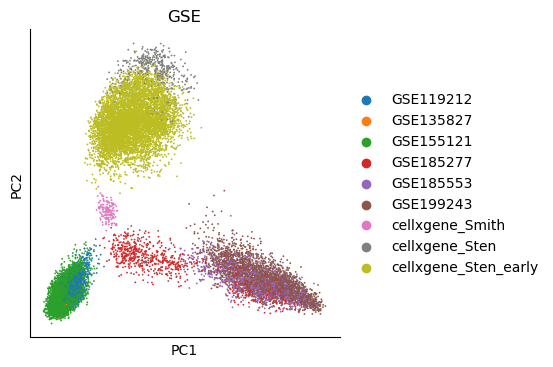

In [65]:
sc.pl.pca(adata_prop,color="GSE",cmap="RdBu_r")

In [68]:
adata_prop

AnnData object with n_obs × n_vars = 18000 × 67814
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'CellClass', 'Region', 'Subregion', 'assay_ontology_term_id', 'donor_id', 'dissection', 'tissue_ontology_term_id', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'cluster_id', 'is_primary_data', 'cell_type', 'assay', 'tissue', 'self_reported_ethnicity', 'development_stage', 'percent.rb', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'GSM', 'GSE', 'batch_n', 'CytoTRACE2_Score', 'CytoTRACE2_Potency', 'CytoTRACE2_Relative', 'CytoTRACE2_Score_factor', 'id', 'Batch', 'Age_.Carnegie_Stage.', 'annot_scANVI_leiden_30_3_256NB_5_res2_V2', 'annot_scANVI_leiden_30_3_256NB_5_res2', 'age_from_batch', 'cell_type_detailed', 'cell_type_general', 'age_upd_grouped2'
    var: 'features', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca

In [69]:
pca_projections = pd.DataFrame(adata_prop.obsm["X_scVI"],index=adata_prop.obs_names)

In [70]:
dm_res = palantir.utils.run_diffusion_maps(pca_projections)
ms_data = palantir.utils.determine_multiscale_space(dm_res, n_eigs=2) ## n_eigs 2-5 

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)


In [72]:
# generate neighbor draph in multiscale diffusion space
adata_prop.obsm["X_palantir"]=ms_data.values
sc.pp.neighbors(adata_prop,n_neighbors=30,use_rep="X_palantir")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)


In [73]:
# draw ForceAtlas2 embedding using 2 first PCs as initial positions
adata_prop.obsm["X_pca2d"]=adata_prop.obsm["X_scVI"][:,:2]
sc.tl.draw_graph(adata_prop,init_pos='X_pca2d')

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:00:49)


In [5]:
pwd

'/home/bnvlab2'

In [6]:
adata_prop

AnnData object with n_obs × n_vars = 18000 × 67814
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'CellClass', 'Region', 'Subregion', 'assay_ontology_term_id', 'donor_id', 'dissection', 'tissue_ontology_term_id', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'cluster_id', 'is_primary_data', 'cell_type', 'assay', 'tissue', 'self_reported_ethnicity', 'development_stage', 'percent.rb', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'GSM', 'GSE', 'batch_n', 'CytoTRACE2_Score', 'CytoTRACE2_Potency', 'CytoTRACE2_Relative', 'CytoTRACE2_Score_factor', 'id', 'Batch', 'Age_.Carnegie_Stage.', 'annot_scANVI_leiden_30_3_256NB_5_res2_V2', 'annot_scANVI_leiden_30_3_256NB_5_res2', 'age_from_batch', 'cell_type_detailed', 'cell_type_general', 'age_upd_grouped2', 't', 'seg', 'edge', 't_sd', 'milestones', 't_bin_custom'
    var: 'features', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'GSM_colors', '_scvi_manager_

In [7]:
import matplotlib.pyplot as plt
import scanpy as sc

# set default figure size (matplotlib)
plt.rcParams["figure.figsize"] = (5, 5)   # change as needed

# make plot and save (scanpy will save into sc.settings.figdir)
sc.settings.figdir = "./figures"          # change folder if you want
sc.pl.draw_graph(
    adata_prop,
    color=["t_bin_custom"],
    color_map="RdBu_r",
    show=False,
    save="atlas_t_bin_custom.pdf",      # filename suffix
)

plt.show()


In [4]:
import matplotlib.pyplot as plt
import scanpy as sc

# set default figure size (matplotlib)
plt.rcParams["figure.figsize"] = (5, 5)   # change as needed

# make plot and save (scanpy will save into sc.settings.figdir)
sc.settings.figdir = "./figures"          # change folder if you want
sc.pl.draw_graph(
    adata_prop,
    color=["cell_type_general"],
    color_map="RdBu_r",
    show=False,
    save="atlas_by_cell_type.pdf",      # filename suffix
)

plt.show()


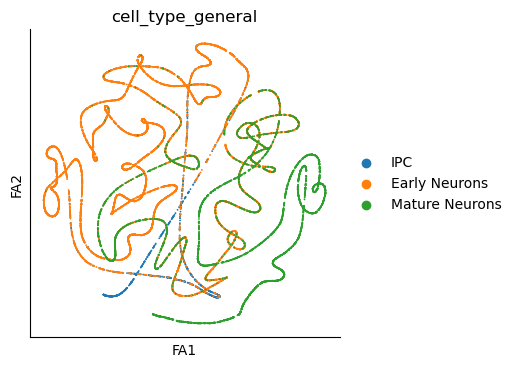

In [74]:
sc.pl.draw_graph(adata_prop,color=["cell_type_general"],color_map="RdBu_r")

In [95]:
scf.tl.tree(adata_prop,method="ppt",
            Nodes=220, ##50
            use_rep="palantir",
            device="cpu",seed=1,
            ppt_lambda=50, ppt_sigma=0.0019, ### ppt_lambda ppt_sigma 0.125
            ppt_nsteps=150 #50
           )


inferring a principal tree --> parameters used 
    220 principal points, sigma = 0.0019, lambda = 50, metric = euclidean
    fitting:  39%|███████████▍                 | 59/150 [00:01<00:03, 29.51it/s]
    converged
    finished (0:00:02) --> added 
    .uns['ppt'], dictionnary containing inferred tree.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'] coordinates of principal points in representation space.


/home/bnvlab2/miniconda3/lib/python3.12/site-packages/simpleppt/utils.py:58: RuntimeWarning: invalid value encountered in divide
  res = (B1.T.dot(A1)).T / np.sqrt(
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/simpleppt/ppt.py:267: RuntimeWarning: divide by zero encountered in log
  sigma / R.shape[0] * np.sum(R * np.log(R)),
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/simpleppt/ppt.py:267: RuntimeWarning: invalid value encountered in multiply
  sigma / R.shape[0] * np.sum(R * np.log(R)),


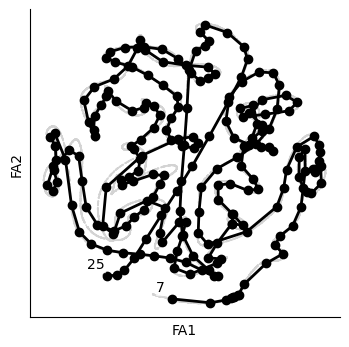

In [96]:
scf.pl.graph(adata_prop)

In [97]:
import gc
gc.collect()

6725

In [98]:
scf.tl.root(adata_prop,25)

node 25 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info'] for each PP, its distance vs root and segment assignment.
    .uns['graph']['pp_seg'] segments network information.


In [99]:
scf.tl.pseudotime(adata_prop,n_jobs=4,n_map=50,seed=42)

projecting cells onto the principal graph
    mappings:   0%|                                      | 0/50 [00:00<?, ?it/s]

/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import

    mappings: 100%|█████████████████████████████| 50/50 [20:59<00:00, 25.18s/it]
    finished (0:21:01) --> added
    .obs['edge'] assigned edge.
    .obs['t'] pseudotime value.
    .obs['seg'] segment of the tree assigned.
    .obs['milestones'] milestone assigned.
    .uns['pseudotime_list'] list of cell projection from all mappings.


In [3]:
import os
import matplotlib.pyplot as plt

# make sure output dir exists
outdir = "./figures"
os.makedirs(outdir, exist_ok=True)

plt.rcParams["figure.figsize"] = (5, 5)

# scFates trajectory plot
fig, ax = plt.subplots()
scf.pl.trajectory(adata_prop, ax=ax, show=False)

fig.savefig(os.path.join(outdir, "atlas_trajectory.pdf"), dpi=300, bbox_inches="tight")
plt.close(fig)


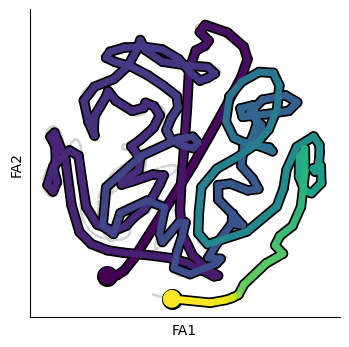

In [100]:
scf.pl.trajectory(adata_prop)

In [101]:
d={ 'IPC': ['EOMES',
  'ASCL1',
  'NEUROG1',
  'NEUROG2',
  'NEUROD1',
  'NEUROD2',
  'NEUROD4',
  'NHLH1',
  'HES6',
  'PPP1R17'],
 'Postmitotic / Immature Neurons': ['TBR1',
  'ELAVL3',
  'ELAVL4',
  'DCX',
  'TUBB3',
  'NEUROD6',
  'STMN2'],
 'Mature Neurons': ['SATB2',
  'BCL11B',
  'RBFOX3',
  'SNAP25',
  'SYT1',
  'MYT1L',
  'MEF2C',
  'GRIN2B',
  'CADM2',
  'RIMS2',
  'NRXN1',
  'SLC17A7']}

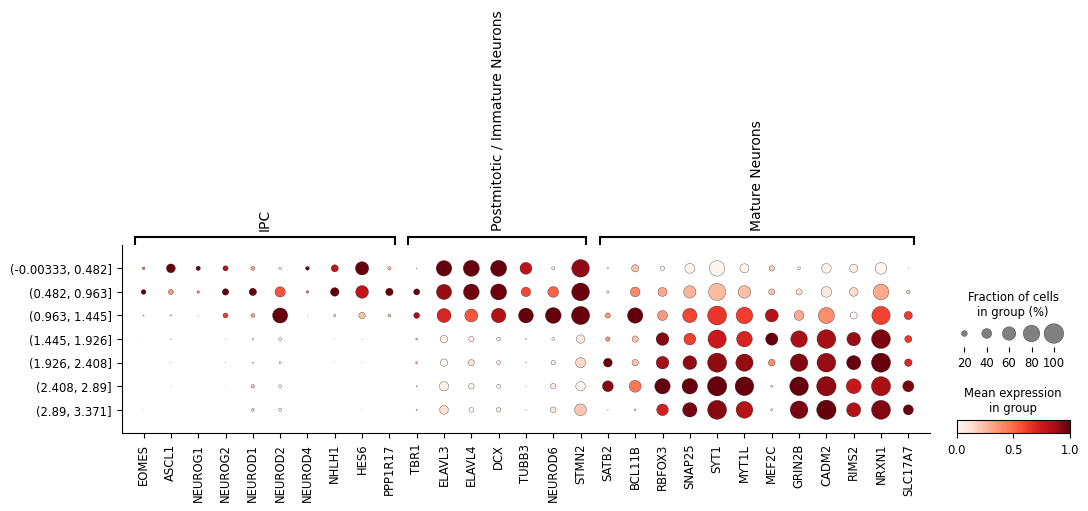

In [102]:
 sc.pl.dotplot(
    adata_prop,
    var_names=d, #NC_neuron,
   # expression_cutoff=1.5,
    groupby=['t'],# 'True_Condition_PSEN'],  # or 'leiden', etc.
    use_raw=False,         # or False if you're working with normalized data
    standard_scale='var', # normalize gene-wise (optional)
  # save='wnt_atlas_dotplot_general.png',
  # dendrogram=True       # optional clustering of groups
)

In [2]:
import scanpy as sc

/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/bnvlab2/miniconda3/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import

In [3]:
adata= sc.read('/home/bnvlab2/scVI_brain_organoids/organoids/neurons_scVI_scFates_atlas2.h5ad')

/tmp/ipykernel_181074/1746758728.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Condition", loc="upper left", bbox_to_anchor=(1.02, 1.0))


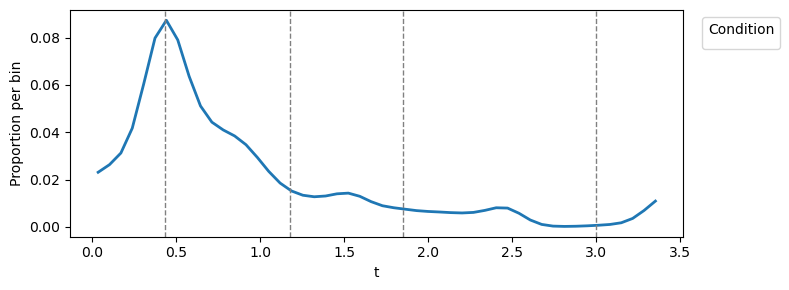

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data
df = adata.obs[['t']].copy()
df['t'] = pd.to_numeric(df['t'], errors='coerce')
df = df.dropna(subset=['t'])
# Smoothing helpers
try:
    from scipy.ndimage import gaussian_filter1d
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

def smooth_proportions(y, gaussian_sigma=1.5, ma_window=7):
    if _HAS_SCIPY:
        return gaussian_filter1d(y.astype(float), sigma=gaussian_sigma, mode='nearest')
    # fallback: Hann moving average
    w = max(3, int(ma_window) | 1)  # force odd, >=3
    kernel = np.hanning(w)
    kernel /= kernel.sum()
    return np.convolve(y.astype(float), kernel, mode='same')

# Binning + plotting
bins = 50        # tweak for resolution
gauss_sigma = 1.5  # increase for smoother; decrease for sharper
ma_window = 7      # used only if SciPy is unavailable

fig, ax = plt.subplots(figsize=(8, 3))

#for cond, sub in df.groupby('True_Condition_PSEN'):
x = df['t'].values
counts, edges = np.histogram(x, bins=bins, density=False)
total = counts.sum()
probs = counts / total if total > 0 else counts
centers = 0.5 * (edges[1:] + edges[:-1])

probs_smooth = smooth_proportions(probs, gaussian_sigma=gauss_sigma, ma_window=ma_window)
# re-normalize to keep area ≈ 1 across bins after smoothing (optional)
area = probs_smooth.sum()
if area > 0:
    probs_smooth = probs_smooth / area


ax.plot(centers, probs_smooth, linewidth=2)

ax.set_xlabel("t")
ax.set_ylabel("Proportion per bin")
ax.legend(title="Condition", loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.subplots_adjust(right=0.78)

#vlines = [0.3, 0.4, 0.53, 0.68, 1.78, 4.23, 4.67]

#vlines = [0.667, 1.334, 2.001, 4.67, 4.003, 2.668, 3.336]

vlines = [0.43, 1.18, 1.85,   3]# 3.8]


for xv in vlines:
    ax.axvline(x=xv, color='gray', linestyle='--', linewidth=1)


plt.tight_layout()

out_png = "atlas_scfates_counts_all.png"
out_pdf = "atlas_scfates_counts_all.pdf"
plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()



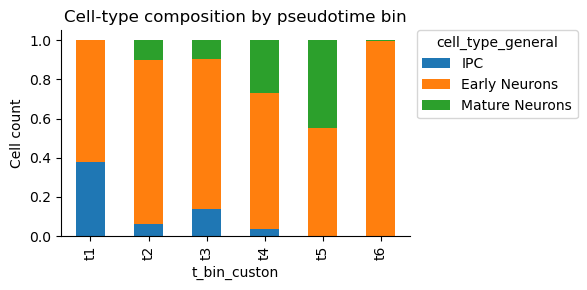

In [117]:
ax = ct.plot(
    kind='bar',
    stacked=True,
    figsize=(6, 3),
   # legend=False
   # color=[palette_cell_types.get(c, '#999999') for c in ct.columns]
)

ax.set_xlabel('t_bin_custon')
ax.set_ylabel('Cell count')
ax.set_title('Cell-type composition by pseudotime bin')
ax.legend(
    title='cell_type_general',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0.
)
plt.tight_layout()
plt.show()

In [129]:
import seaborn as sns

<Axes: xlabel='cell_type_general', ylabel='t'>

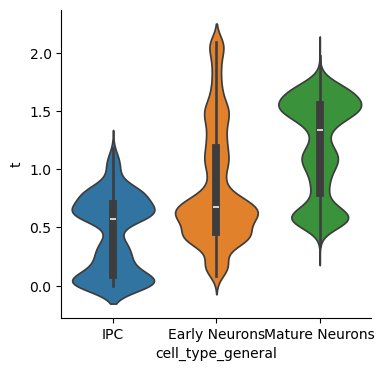

In [130]:
sns.violinplot(data=df, y='t', x='cell_type_general',  hue='cell_type_general', legend=False)